In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # use GPU 1

from dingo.core.posterior_models.build_model import build_model_from_kwargs

main_pm = build_model_from_kwargs(
    filename="/scratch/tpausch/models/ET_T2/model_latest.pt",
    device="cuda",
    load_training_info=False,
)



In [22]:
import os
import pickle
import numpy as np

true_cm = []
mass_ratio_error = []
mass_ratio_std = []
chirp_mass_error = []
chirp_mass_std = []


result_files = sorted(os.listdir("results"))

for fname in result_files:

    with open(f"results/{fname}", "rb") as f:
        payload = pickle.load(f)

    theta_true = payload["theta_true"]
    result = payload["result"]

    posterior_samples = result.samples

    q_samples = np.array(posterior_samples["mass_ratio"])

    # inference statistics
    q_mean = np.mean(q_samples)
    q_std = np.std(q_samples)

    true_q = theta_true["mass_ratio"]

    cm_samples = np.array(posterior_samples["chirp_mass"])

    cm_mean = np.mean(cm_samples)
    cm_std = np.std(cm_samples)

    

    true_cm.append(theta_true["chirp_mass"])
    mass_ratio_error.append(q_mean - true_q)
    mass_ratio_std.append(q_std)
    chirp_mass_error.append(cm_mean - theta_true["chirp_mass"])
    chirp_mass_std.append(cm_std)

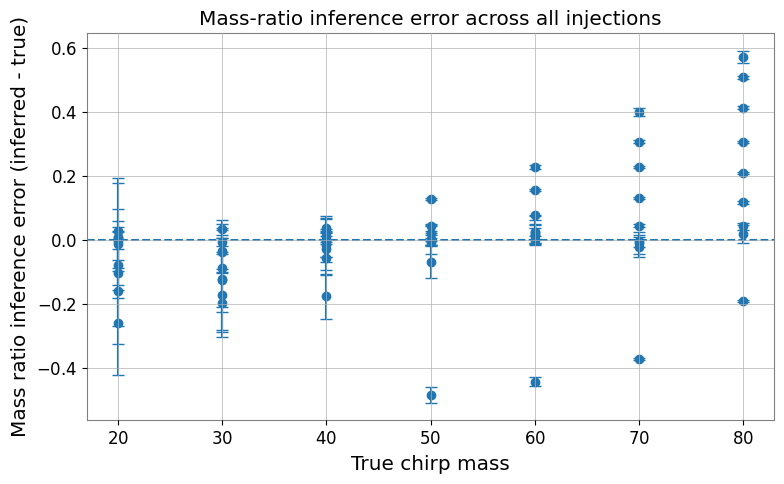

In [23]:
import matplotlib.pyplot as plt
import numpy as np

true_cm = np.array(true_cm)
mass_ratio_error = np.array(mass_ratio_error)
mass_ratio_std = np.array(mass_ratio_std)

plt.figure(figsize=(8, 5))

plt.errorbar(
    true_cm,
    mass_ratio_error,
    yerr=mass_ratio_std,
    fmt="o",
    capsize=4,
)

plt.axhline(0, linestyle="--")

plt.xlabel("True chirp mass")
plt.ylabel("Mass ratio inference error (inferred - true)")
plt.title("Mass-ratio inference error across all injections")

plt.grid(True)
plt.tight_layout()
plt.show()

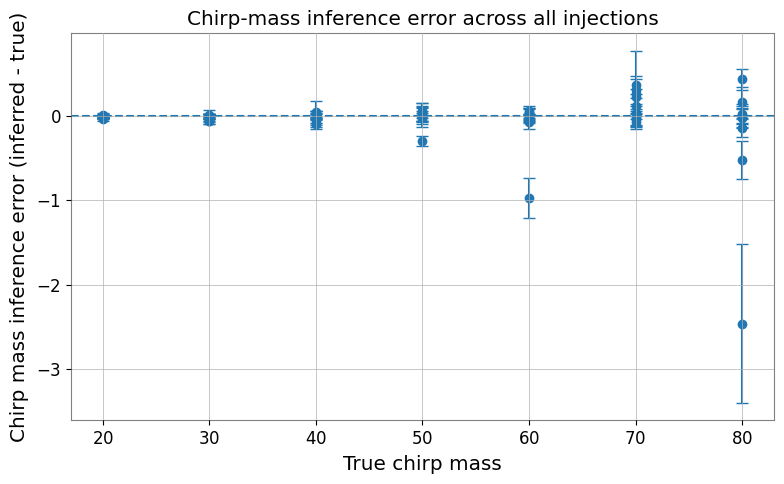

In [24]:
import matplotlib.pyplot as plt
import numpy as np

true_cm = np.array(true_cm)
chirp_mass_error = np.array(chirp_mass_error)
chirp_mass_std = np.array(chirp_mass_std)

plt.figure(figsize=(8, 5))

plt.errorbar(
    true_cm,
    chirp_mass_error,
    yerr=chirp_mass_std,
    fmt="o",
    capsize=4,
)

plt.axhline(0, linestyle="--")

plt.xlabel("True chirp mass")
plt.ylabel("Chirp mass inference error (inferred - true)")
plt.title("Chirp-mass inference error across all injections")

plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
pp_values_chirp_mass = []
pp_values_mass_ratio = []

In [12]:
result_files = sorted(os.listdir("results"))

for fname in result_files:

    with open(f"results/{fname}", "rb") as f:

        payload = pickle.load(f)

        theta_true = payload["theta_true"]
        result = payload["result"]

        posterior_samples = result.samples


        # ============================================================
        # Chirp mass PP value
        # ============================================================

        cm_samples = posterior_samples["chirp_mass"]

        pp_cm = np.mean(
            cm_samples < theta_true["chirp_mass"]
        )

        pp_values_chirp_mass.append(pp_cm)


        # ============================================================
        # Mass ratio PP value
        # ============================================================

        q_samples = posterior_samples["mass_ratio"]

        pp_q = np.mean(
            q_samples < theta_true["mass_ratio"]
        )

        pp_values_mass_ratio.append(pp_q)

In [16]:
import matplotlib.pyplot as plt


def plot_pp(pp_values, label):

    pp_values = np.array(pp_values)

    sorted_pp = np.sort(pp_values)

    n = len(sorted_pp)

    empirical_cdf = np.arange(1, n + 1) / n

    x = np.linspace(0, 1, 200)

    sigma = np.sqrt(x * (1 - x) / n)

    plt.figure(figsize=(6, 6))

    # Ideal calibration
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Ideal calibration",
    )


    # Empirical PP curve
    plt.plot(
        sorted_pp,
        empirical_cdf,
        marker="o",
        label=label,
    )

    plt.xlabel("Credible level")
    plt.ylabel("Fraction of injections")

    plt.title(f"PP Plot: {label}")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

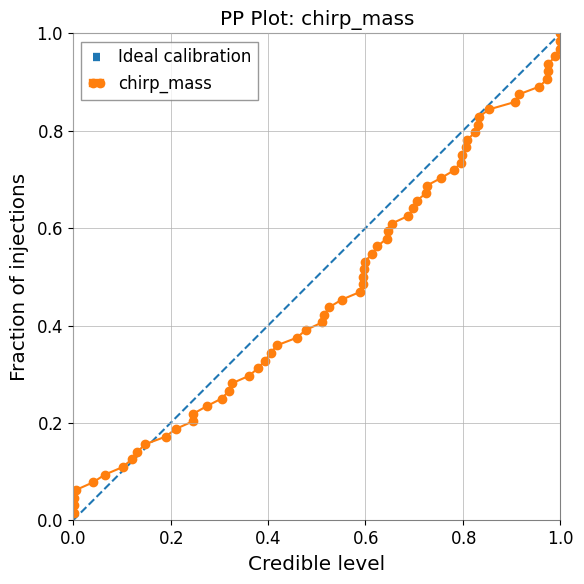

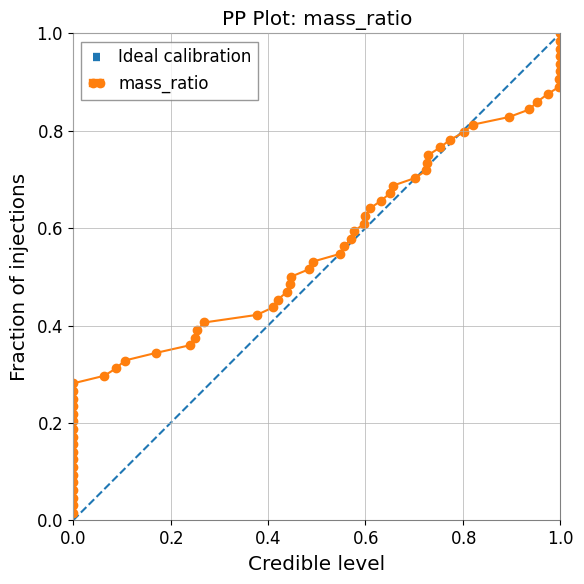

In [17]:
plot_pp(
    pp_values_chirp_mass,
    "chirp_mass",
)

plot_pp(
    pp_values_mass_ratio,
    "mass_ratio",
)